# Electricity Price & Production Analysis

Weather, Production, and Market Structure

### 1. Imports & Setup

In [28]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import glob
import os

from IPython.display import display

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

#### 1.1 Functions

In [29]:
def normalize_datetime(df, colname):
    """Converts a datetime column to a UTC datetime column."""
    df = df.rename(columns={colname: 'datetime'})
    df['datetime'] = pd.to_datetime(df['datetime'], utc=True, errors='coerce')
    return df


def calculate_dk_area(row, area_column, area_type):
    """Calculates the dk area for a given column."""
    try:
        if area_type == 'area':
            return str(row[area_column])[6]
        elif area_type == 'municipality':
            return "1" if int(row[area_column]) > 400 else "2"
        elif area_type == 'longitude':
            val = row[area_column]
            if pd.isnull(val):
                return None
            try:
                val = float(val)
                return '1' if val < 11 else '2'
            except ValueError:
                return None
    except Exception:
        return None

#### 1.2 Municipality Dataset

Used to assign the correct municipalities to the datasets containing weather stations

In [30]:
# Load the municipality coordinates dataset
municipality_to_coordinates = pd.read_csv('municipality_codes_to_coordinates.csv')
municipality_coords = municipality_to_coordinates[['latitude', 'longitude']].to_numpy()
municipality_codes = municipality_to_coordinates['code'].to_numpy()


def calculate_municipality_code(row):
    try:
        lat, lon = row['latitude'], row['longitude']
        if pd.isnull(lat) or pd.isnull(lon): return None
        input_coord = np.array([lat, lon])

        # Scaling longitude by 0.57 accounts for the Earth's curvature in Denmark.
        diff = (municipality_coords - input_coord) * np.array([1.0, 0.57])
        distances = np.sum(diff ** 2, axis=1)
        return municipality_codes[np.argmin(distances)]
    except Exception:
        return None

### 2. Data Loading & Basic Preparation

#### 2.1 Day Ahead Prices

In [31]:
csv_files = glob.glob(os.path.join('DayAheadPrices', '*.csv'))
day_ahead = pd.concat((pd.read_csv(f) for f in csv_files), ignore_index=True)
day_ahead = day_ahead.drop(columns=['Intraday Period (UTC)', 'Intraday Price (EUR/MWh)'])

day_ahead['MTU (UTC)'] = day_ahead['MTU (UTC)'].str.split(' - ').str[1]
day_ahead['MTU (UTC)'] = pd.to_datetime(day_ahead['MTU (UTC)'], format='%d/%m/%Y %H:%M:%S', utc=True)
day_ahead['CalculatedDKArea'] = day_ahead.apply(lambda row: calculate_dk_area(row, 'Area', 'area'), axis=1)

display(day_ahead)

,MTU (UTC),Area,Sequence,Day-ahead Price (EUR/MWh),CalculatedDKArea
0,2021-01-01 00:00:00+00:00,BZN|DK1,Without Sequence,50.87,1
1,2021-01-01 01:00:00+00:00,BZN|DK1,Without Sequence,48.19,1
2,2021-01-01 02:00:00+00:00,BZN|DK1,Without Sequence,44.68,1
3,2021-01-01 03:00:00+00:00,BZN|DK1,Without Sequence,42.92,1
4,2021-01-01 04:00:00+00:00,BZN|DK1,Without Sequence,40.39,1
...,...,...,...,...,...
82601,2025-09-17 18:00:00+00:00,BZN|DK2,Without Sequence,130.82,2
82602,2025-09-17 19:00:00+00:00,BZN|DK2,Without Sequence,119.35,2
82603,2025-09-17 20:00:00+00:00,BZN|DK2,Without Sequence,90.81,2
82604,2025-09-17 21:00:00+00:00,BZN|DK2,Without Sequence,76.18,2


#### 2.2 Consumption

In [32]:
csv_files = glob.glob(os.path.join('dmi/datasets/Consumption data in months', '*.csv'))
consumption = pd.concat((pd.read_csv(f) for f in csv_files), ignore_index=True)
consumption['TimeUTC'] = pd.to_datetime(consumption['TimeUTC'], format='%Y-%m-%dT%H:%M:%S')
consumption['TimeUTC'] = consumption['TimeUTC'].dt.strftime('%Y-%m-%dT%H:%M:%SZ')
consumption['CalculatedDKArea'] = consumption.apply(
    lambda row: calculate_dk_area(row, 'MunicipalityCode', 'municipality'), axis=1)

display(consumption)

,ConsumptionkWh,HeatingCategory,HousingCategory,Municipality,MunicipalityCode,RegionName,TimeDK,TimeUTC,CalculatedDKArea
0,1902.440,Andet,Andet,København,101,Region Hovedstaden,2022-09-30T23:00:00,2022-09-30T21:00:00Z,2
1,17.150,Elvarme eller varmepumpe,Andet,København,101,Region Hovedstaden,2022-09-30T23:00:00,2022-09-30T21:00:00Z,2
2,34816.125,Andet,Etageejendom,København,101,Region Hovedstaden,2022-09-30T23:00:00,2022-09-30T21:00:00Z,2
3,220.740,Elvarme eller varmepumpe,Etageejendom,København,101,Region Hovedstaden,2022-09-30T23:00:00,2022-09-30T21:00:00Z,2
4,206.520,Andet,Fritidshuse,København,101,Region Hovedstaden,2022-09-30T23:00:00,2022-09-30T21:00:00Z,2
...,...,...,...,...,...,...,...,...,...
16473330,52.652,Elvarme eller varmepumpe,Etageejendom,Hjørring,860,Region Nordjylland,2025-10-01T00:00:00,2025-09-30T22:00:00Z,1
16473331,121.220,Andet,Fritidshuse,Hjørring,860,Region Nordjylland,2025-10-01T00:00:00,2025-09-30T22:00:00Z,1
16473332,1394.092,Elvarme eller varmepumpe,Fritidshuse,Hjørring,860,Region Nordjylland,2025-10-01T00:00:00,2025-09-30T22:00:00Z,1
16473333,8713.867,Andet,Parcel- og rækkehuse,Hjørring,860,Region Nordjylland,2025-10-01T00:00:00,2025-09-30T22:00:00Z,1


#### 2.3 Sunlight

In [33]:
stations = pd.read_csv('dmi/datasets/dmi_sunlight_stations.csv', delimiter=',')

csv_files = glob.glob(os.path.join('dmi/datasets', '*radiation.csv'))
sunlight = pd.concat((pd.read_csv(f) for f in csv_files), ignore_index=True)

# Force timezone UTC
sunlight['timeObserved'] = pd.to_datetime(sunlight['timeObserved'], format='mixed', utc=True)

# Convert to ISO 8601 with Z suffix
sunlight['timeObserved'] = sunlight['timeObserved'].dt.strftime('%Y-%m-%dT%H:%M:%SZ')

# Remove duplicates
sunlight = sunlight.drop_duplicates(subset=['timeObserved', 'stationId'], keep='first')

sunlight = sunlight.merge(stations[['station_id', 'latitude', 'longitude']],
                          left_on='stationId',
                          right_on='station_id',
                          how='left')

sunlight['CalculatedDKArea'] = sunlight.apply(lambda row: calculate_dk_area(row, 'longitude', 'longitude'), axis=1)
sunlight['MunicipalityCode'] = sunlight.apply(lambda row: calculate_municipality_code(row), axis=1)

sunlight = sunlight.rename(
    columns={'latitude': 'sun_latitude', 'longitude': 'sun_longitude', 'stationId': 'sun_station_id'})
sunlight = sunlight.drop(columns=['station_id', 'direct_solar_exposure'])

display(sunlight)

,timeObserved,sun_station_id,stationName,mean_radiation,sun_latitude,sun_longitude,CalculatedDKArea,MunicipalityCode
0,2020-01-01T00:00:00Z,6019,Silstrup,0.0,56.9300,8.6412,1,787
1,2020-01-01T01:00:00Z,6019,Silstrup,0.0,56.9300,8.6412,1,787
2,2020-01-01T02:00:00Z,6019,Silstrup,0.0,56.9300,8.6412,1,787
3,2020-01-01T03:00:00Z,6019,Silstrup,0.0,56.9300,8.6412,1,787
4,2020-01-01T04:00:00Z,6019,Silstrup,0.0,56.9300,8.6412,1,787
...,...,...,...,...,...,...,...,...
1425195,2025-10-22T06:00:00Z,6197,Nexø Vest,17.0,55.0557,15.0953,2,400
1425196,2025-10-22T07:00:00Z,6197,Nexø Vest,54.0,55.0557,15.0953,2,400
1425197,2025-10-22T08:00:00Z,6197,Nexø Vest,176.0,55.0557,15.0953,2,400
1425198,2025-10-22T09:00:00Z,6197,Nexø Vest,214.0,55.0557,15.0953,2,400


#### 2.4 Wind

In [34]:
stations = pd.read_csv('dmi/datasets/dmi_wind_stations.csv', delimiter=',')

csv_files = glob.glob(os.path.join('dmi/datasets', '*wind.csv'))
wind = pd.concat((pd.read_csv(f) for f in csv_files), ignore_index=True)

wind['timeObserved'] = pd.to_datetime(wind['timeObserved'], format='mixed', utc=True)

# Convert to ISO 8601 with Z suffix
wind['timeObserved'] = wind['timeObserved'].dt.strftime('%Y-%m-%dT%H:%M:%SZ')
# Remove duplicates
wind = wind.drop_duplicates(subset=['timeObserved', 'stationId'], keep='first')

wind = wind.merge(stations[['station_id', 'latitude', 'longitude']],
                  left_on='stationId',
                  right_on='station_id',
                  how='left')

wind["CalculatedDKArea"] = wind.apply(lambda row: calculate_dk_area(row, "longitude", "longitude"), axis=1)
wind['MunicipalityCode'] = wind.apply(lambda row: calculate_municipality_code(row), axis=1)

wind = wind.rename(
    columns={'latitude': 'wind_latitude', 'longitude': 'wind_longitude', 'stationId': 'wind_station_id'})
wind = wind.drop(columns=['station_id'])

display(wind)

,timeObserved,wind_station_id,stationName,mean_wind_speed,wind_latitude,wind_longitude,CalculatedDKArea,MunicipalityCode
0,2020-01-01T00:00:00Z,6019,Silstrup,6.3,56.9300,8.6412,1,787
1,2020-01-01T01:00:00Z,6019,Silstrup,7.0,56.9300,8.6412,1,787
2,2020-01-01T02:00:00Z,6019,Silstrup,8.2,56.9300,8.6412,1,787
3,2020-01-01T03:00:00Z,6019,Silstrup,8.0,56.9300,8.6412,1,787
4,2020-01-01T04:00:00Z,6019,Silstrup,8.6,56.9300,8.6412,1,787
...,...,...,...,...,...,...,...,...
2422252,2024-12-31T20:00:00Z,6197,Nexø Vest,9.3,55.0557,15.0953,2,400
2422253,2024-12-31T21:00:00Z,6197,Nexø Vest,10.4,55.0557,15.0953,2,400
2422254,2024-12-31T22:00:00Z,6197,Nexø Vest,10.6,55.0557,15.0953,2,400
2422255,2024-12-31T23:00:00Z,6197,Nexø Vest,11.3,55.0557,15.0953,2,400


#### 2.5 Merging the datasets

In [35]:
# 1. Normalize datetimes
day_ahead = normalize_datetime(day_ahead, 'MTU (UTC)')
consumption = normalize_datetime(consumption, 'TimeUTC')
sunlight = normalize_datetime(sunlight, 'timeObserved')
wind = normalize_datetime(wind, 'timeObserved')

# 1. Aggregate Sunlight and Wind to Municipality Level
sunlight_agg = sunlight.groupby(['datetime', 'MunicipalityCode'], as_index=False).agg({
    'mean_radiation': 'mean',
    'CalculatedDKArea': 'first'
})

wind_agg = wind.groupby(['datetime', 'MunicipalityCode'], as_index=False).agg({
    'mean_wind_speed': 'mean'
})

# 2. Aggregate Consumption (summing all categories)
consumption_agg = consumption.groupby(['datetime', 'MunicipalityCode'], as_index=False).agg({
    'ConsumptionkWh': 'sum',
    'Municipality': 'first',
    'RegionName': 'first'
})

# 3. Merge Weather and Consumption (Inner join removes 2020-2021 rows)
merged = pd.merge(sunlight_agg, wind_agg, on=['datetime', 'MunicipalityCode'], how='inner')
merged = pd.merge(merged, consumption_agg, on=['datetime', 'MunicipalityCode'], how='inner')

# 4. Attach Prices based on the DK Area (1 or 2)
merged = pd.merge(merged, day_ahead[['datetime', 'CalculatedDKArea', 'Day-ahead Price (EUR/MWh)']],
                 on=['datetime', 'CalculatedDKArea'], how='left')

# 5. Clean up any remaining NaNs in metadata only
metadata_cols = ['Municipality', 'RegionName']
for col in metadata_cols:
    merged[col] = merged.groupby('MunicipalityCode')[col].transform(lambda x: x.ffill().bfill())

merged = merged.dropna(subset=['mean_wind_speed', 'ConsumptionkWh', 'Day-ahead Price (EUR/MWh)'])

#### 2.6 Calculating Production
##### 2.6.1 Preparing Data

In [36]:
solar = pd.read_csv('productionData/solar_panels.csv', delimiter=',')
solar.sort_values(by=['kommune'], inplace=True)
solar = solar.drop(columns=['kw_smaa', 'kw_mellem', 'kw_store', 'anl_total', 'anl_smaa', 'anl_mellem', 'anl_store'])

windmills = pd.read_csv('productionData/windmills.csv', delimiter=',')
windmills = windmills.drop(columns=['Shortest distance', 'Average distance', 'Longest distance', 'Inhabitants'])
for city, code in municipality_to_coordinates[['name', 'code']].values:
    windmills.loc[windmills['Kommune'] == city, 'code'] = code
windmills['code'] = windmills['code'].astype(int)

##### 2.6.2 Calculating the production

In [50]:
# --- 1) Ensure key types align ---
merged['MunicipalityCode'] = merged['MunicipalityCode'].astype(int)
solar['komnr'] = solar['komnr'].astype(int)

# If windmills has municipality codes, align that; else aggregate by code first
if 'MunicipalityCode' in windmills.columns:
    windmills['MunicipalityCode'] = windmills['MunicipalityCode'].astype(int)
    wind_by_muni = windmills.groupby('MunicipalityCode')['Installed capacity [kW]'].sum()
else:
    # If 'code' is already municipality code, we'll use that, but ensure it's str
    windmills['code'] = windmills['code'].astype(int)
    wind_by_muni = windmills.set_index('code')['Installed capacity [kW]']

# --- 2) Make capacity columns numeric ---
def to_numeric_clean(s):
    return (s.astype(str)
            .str.replace(r'[^0-9\.\-]', '', regex=True)
            .replace('', np.nan)
            .astype(float))

solar_lookup = to_numeric_clean(solar.set_index('komnr')['kw_total'])
wind_lookup = to_numeric_clean(wind_by_muni)

# --- 3) Map capacities ---
merged['pv_kw']   = merged['MunicipalityCode'].map(solar_lookup).fillna(0.0)
merged['wind_kw'] = merged['MunicipalityCode'].map(wind_lookup).fillna(0.0)

# --- 4) Wind speed: to numeric and unit-check ---
merged['mean_wind_speed'] = pd.to_numeric(merged['mean_wind_speed'], errors='coerce')

# --- 5) Capacity factor using pd.cut bins ---
bins  = [-np.inf, 3, 4, 5, 6, 7, 8, 9, 10, 12, 25, np.inf]
cfvals = [0, 0.05, 0.12, 0.22, 0.35, 0.50, 0.65, 0.80, 0.95, 0.90, 0]

merged['wind_cf'] = pd.cut(merged['mean_wind_speed'], bins=bins, labels=False)
merged['wind_cf'] = merged['wind_cf'].map(dict(enumerate(cfvals))).astype(float).fillna(0.0)

# Optional: use 1.0 between 12 and cut-out
# cfvals = [0, 0.05, 0.12, 0.22, 0.35, 0.50, 0.65, 0.80, 0.95, 1.00, 0]

# --- 6) Outputs ---
merged['wind_kw_out'] = merged['wind_kw'] * merged['wind_cf']

merged['mean_radiation'] = pd.to_numeric(merged['mean_radiation'], errors='coerce')
merged['pv_kwh'] = merged['pv_kw'] * (merged['mean_radiation'] / 1000.0) * 0.15

merged['total_kwh'] = merged['pv_kwh'] + merged['wind_kw_out']

display(merged)

PV capacity sum [kW]: 44217157352.0
Wind capacity sum [kW]: 43000122745.0
Any non-numeric wind speeds: 0
   MunicipalityCode     pv_kw   wind_kw  mean_wind_speed  wind_cf  \
0               223    4224.0       0.0         0.700000      0.0   
1               259   20043.0    3950.0         0.800000      0.0   
2               316   50802.0   59800.0         0.000000      0.0   
3               330   72881.0   43570.0         1.666667      0.0   
4               360  301334.0  275045.0         2.700000      0.0   

   wind_kw_out    pv_kwh  total_kwh  
0          0.0  0.000000   0.000000  
1          0.0  0.000000   0.000000  
2          0.0  0.000000   0.000000  
3          0.0  5.466075   5.466075  
4          0.0  0.000000   0.000000  


In [51]:
df = merged.copy()

df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values("datetime").reset_index(drop=True)

### 3. Time-Based Features (used throughout)

In [52]:
df["hour"] = df["datetime"].dt.hour
df["dayofweek"] = df["datetime"].dt.dayofweek
df["month"] = df["datetime"].dt.month
df["is_weekend"] = df["dayofweek"] >= 5

### 4. Correlation Matrix

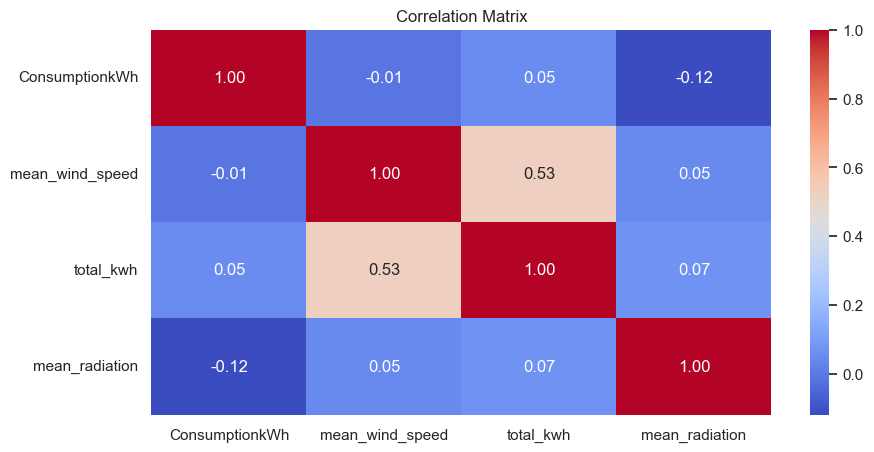

In [53]:
correlation_matrix = df[['ConsumptionkWh', 'mean_wind_speed', 'total_kwh', 'mean_radiation']].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix")
plt.show()

## Layer 1 — Physical System: Energy Production

Goal: Understand how weather drives production
Prices are not used here

### Weather → Production Relationships
#### 4.1 PV Production vs Sunshine & Wind Production vs Wind Speed

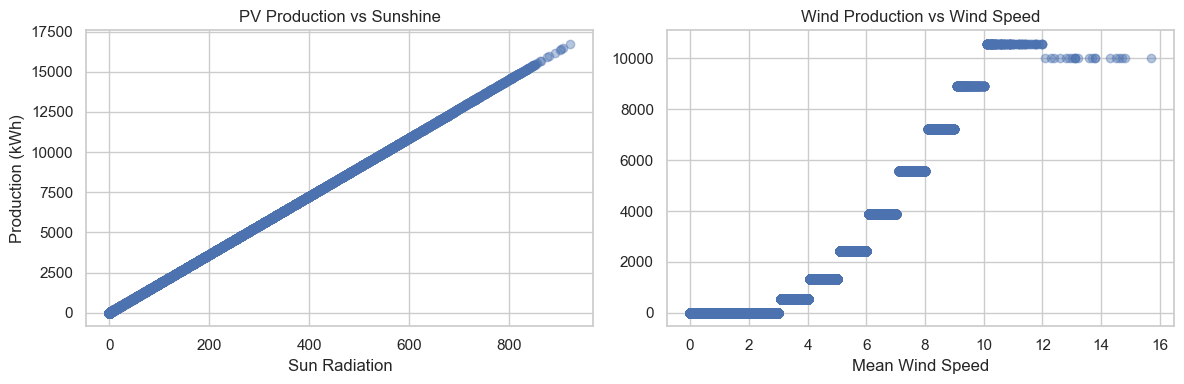

In [54]:
odense_df = df[df['MunicipalityCode'] == 461]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(
    data=odense_df,
    x="mean_radiation",
    y="pv_kwh",
    alpha=0.4
)
axes[0].set_title("PV Production vs Sunshine")
axes[0].set_ylabel("Production (kWh)")
axes[0].set_xlabel("Sun Radiation")
axes[1].scatter(
    data=odense_df,
    x="mean_wind_speed",
    y="wind_kw_out",
    alpha=0.4
)
axes[1].set_title("Wind Production vs Wind Speed")
axes[1].set_xlabel("Mean Wind Speed")
plt.tight_layout()
plt.show()

### 5. Production Correlations (Non-Linear)

In [55]:
production_cols = [
    "pv_kwh",
    "wind_kw_out",
    "mean_radiation",
    "mean_wind_speed",
    # "temperature"
]
active_production = df[df['pv_kwh'] > 0]
df[production_cols].corr(method="spearman")

,pv_kwh,wind_kw_out,mean_radiation,mean_wind_speed
pv_kwh,1.000000,0.108587,0.967923,0.082867
wind_kw_out,0.108587,1.000000,0.077807,0.858249
mean_radiation,0.967923,0.077807,1.000000,0.091401
mean_wind_speed,0.082867,0.858249,0.091401,1.000000


Note: Spearman correlation is used to capture monotonic but non-linear relationships.

### 6. Seasonal Structure of Production

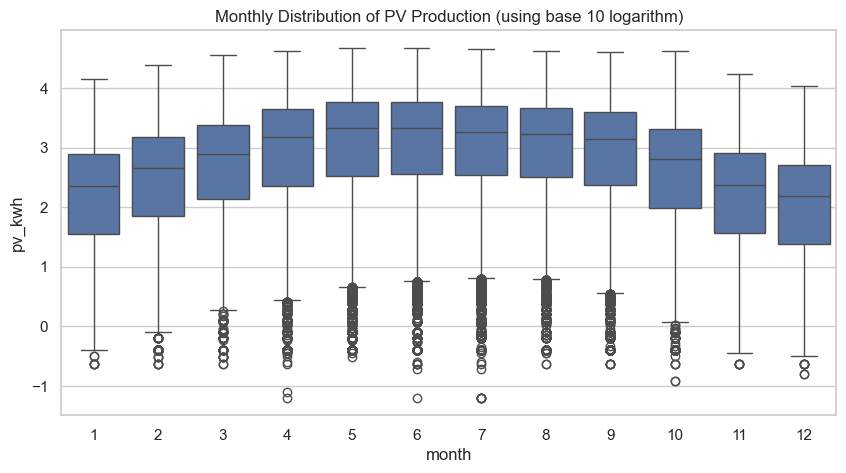

In [56]:
sns.boxplot(
    data=active_production,
    x="month",
    y=np.log10(active_production["pv_kwh"])
)
plt.title("Monthly Distribution of PV Production (using base 10 logarithm)")
plt.show()

## Layer 2 — Market Behavior: Electricity Prices

Goal: Understand price dynamics independent of production**

### 7. Price Overview

In [57]:
df["Day-ahead Price (EUR/MWh)"].describe()

count    472872.000000
mean         97.671913
std          89.111009
min        -440.100000
25%          47.410000
50%          83.900000
75%         115.980000
max         936.310000
Name: Day-ahead Price (EUR/MWh), dtype: float64

### 8. Intraday Price Structure

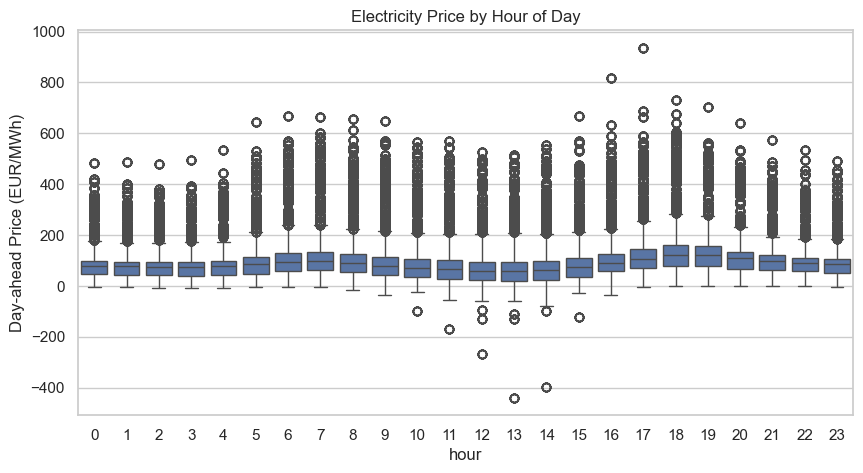

In [58]:
sns.boxplot(
    data=df,
    x="hour",
    y="Day-ahead Price (EUR/MWh)"
)
plt.title("Electricity Price by Hour of Day")
plt.show()

### 9. Weekly & Seasonal Effects

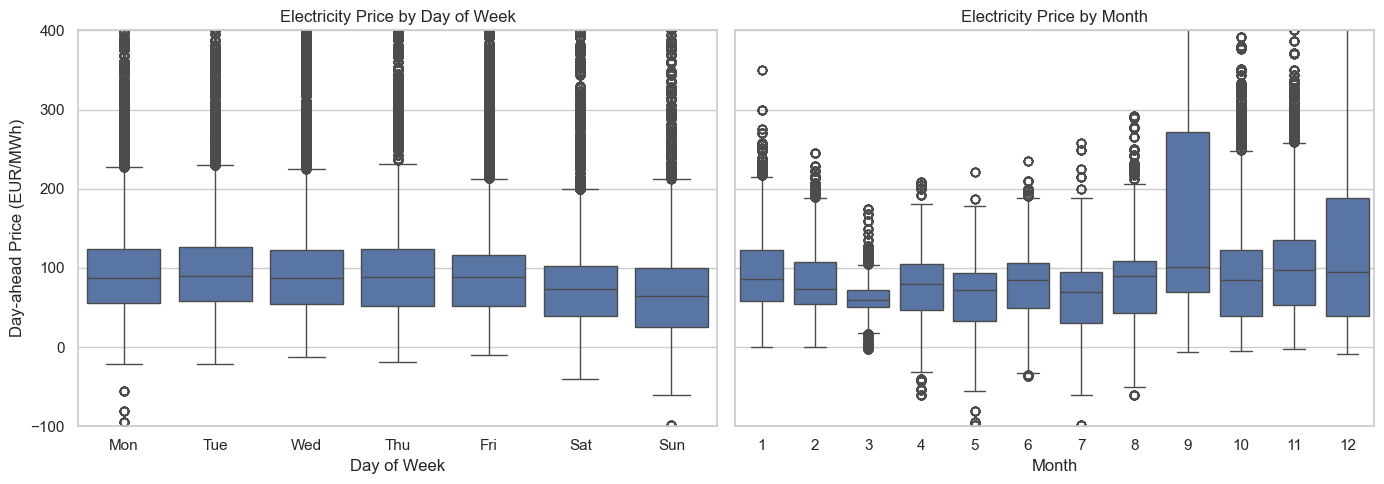

In [59]:
days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# --- Left plot: Day of week ---
sns.boxplot(
    data=df,
    x="dayofweek",
    y="Day-ahead Price (EUR/MWh)",
    ax=axes[0]
)
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(days)
axes[0].set_xlabel("Day of Week")
axes[0].set_title("Electricity Price by Day of Week")
axes[0].set_ylim(-100, 400)

# --- Right plot: Month ---
sns.boxplot(
    data=df,
    x="month",
    y="Day-ahead Price (EUR/MWh)",
    ax=axes[1]
)
axes[1].set_xlabel("Month")
axes[1].set_title("Electricity Price by Month")
axes[1].set_ylim(-100, 400)

plt.tight_layout()
plt.show()

## Layer 3 — Coupling: Production & Price Interaction

Goal: Understand when production matters for prices**

### 10. Conditional Effects (High Demand Hours)

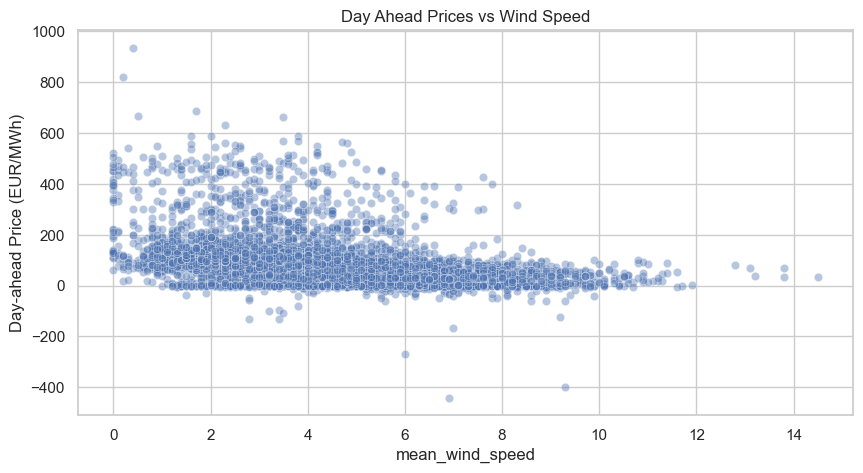

In [60]:
sns.scatterplot(
    data=odense_df[odense_df["hour"].between(11, 17)],
    x="mean_wind_speed",
    y="Day-ahead Price (EUR/MWh)",
    alpha=0.4
)
plt.title("Day Ahead Prices vs Wind Speed")
plt.show()